In [1]:
import sys

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms

from fuzzy_pooling import FuzzyPooling

# Use CUDA when it is available, with a clear diagnostic when it is not.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pin_memory = device.type == "cuda"
# A single-process loader gives identical ordering across methods and works
# consistently in notebook and restricted execution environments.
num_workers = 0

# Reproducible comparison configuration. The paper specifies SGD and a
# batch size of 32, but does not report its learning rate or epoch count.
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
if device.type == "cuda":
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

batch_size = 32
learning_rate = 0.01
momentum = 0.9
num_epochs = 50
eval_every = 5

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA is unavailable; training will run on the CPU.")

Python: c:\Program Files\Python311\python.exe
PyTorch: 2.5.1+cpu
Device: cpu


In [2]:
class LeNet(nn.Module):

    def __init__(self, pool=nn.MaxPool2d(kernel_size=2, stride=2)
):
        super(LeNet, self).__init__()
        # 3 input image channel, 6 output feature maps and 5x5 conv kernel
        self.cn1 = nn.Conv2d(3, 6, 5)
        # 6 input image channel, 16 output feature maps and 5x5 conv kernel
        self.cn2 = nn.Conv2d(6, 16, 5)
        # fully connected layers of size 120, 84 and 10
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5 is the spatial dimension at this layer
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.pool = pool
        self.relu = nn.ReLU6()

    def forward(self, x):
        # Convolution with 5x5 kernel
        x = self.relu(self.cn1(x))
        # Max pooling over a (2, 2) window
        x = self.pool(x)
        # Convolution with 5x5 kernel
        x = self.relu(self.cn2(x))
        # Max pooling over a (2, 2) window
        x = self.pool(x)
        # Flatten spatial and depth dimensions into a single vector
        x = x.view(-1, self.flattened_features(x))
        # Fully connected operations
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def flattened_features(self, x):
        # all except the first (batch) dimension
        size = x.size()[1:]  
        num_feats = 1
        for s in size:
            num_feats *= s
        return num_feats

In [3]:
criterion = nn.CrossEntropyLoss()

def train(net, trainloader, optim, epoch):
    net.train()
    loss_total = 0.0

    for ip, ground_truth in trainloader:
        ip = ip.to(device, non_blocking=True)
        ground_truth = ground_truth.to(device, non_blocking=True)

        optim.zero_grad(set_to_none=True)

        op = net(ip)
        loss = criterion(op, ground_truth)
        loss.backward()
        optim.step()

        loss_total += loss.item()

    avg_loss = loss_total / len(trainloader)
    print(f"Epoch {epoch + 1} - Training Loss: {avg_loss:.3f}")

In [4]:
def test(net, testloader):
    net.eval()
    success = 0
    counter = 0

    with torch.inference_mode():
        for im, ground_truth in testloader:
            im = im.to(device, non_blocking=True)
            ground_truth = ground_truth.to(device, non_blocking=True)

            op = net(im)
            pred = op.argmax(dim=1)

            counter += ground_truth.size(0)
            success += (pred == ground_truth).sum().item()

    accuracy = 100 * success / counter
    print(f"LeNet accuracy on {counter} test images: {accuracy:.1f} %")
    return accuracy

In [5]:
# The paper reports no preprocessing or data augmentation. ToTensor only
# converts PIL images to float tensors in [0, 1].
transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)

def make_trainloader():
    # Recreate the generator so every pooling method sees the same batches.
    generator = torch.Generator().manual_seed(seed)
    return torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, generator=generator,
        num_workers=num_workers, pin_memory=pin_memory,
        persistent_workers=num_workers > 0,
    )

trainloader = make_trainloader()

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=num_workers > 0,
)

classes = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

Files already downloaded and verified
Files already downloaded and verified


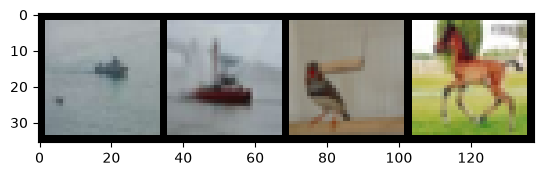

    ship  ||  ship  ||  bird  ||  horse


In [6]:
# define a function that displays an image
def imageshow(image):
    npimage = image.numpy()
    plt.imshow(np.transpose(npimage, (1, 2, 0)))
    plt.show()


# sample images from training set
dataiter = iter(trainloader)
images, labels = next(dataiter)

# display images in a grid
num_images = 4
imageshow(torchvision.utils.make_grid(images[:num_images]))
# print labels
print('    '+'  ||  '.join(classes[labels[j]] for j in range(num_images)))

### MaxPooling

In [7]:
torch.manual_seed(seed)
lenet_max = LeNet(pool=nn.MaxPool2d(kernel_size=2, stride=2)).to(device)

In [8]:
# Define the optimizer.
optim_max = torch.optim.SGD(
    lenet_max.parameters(), lr=learning_rate, momentum=momentum
)
trainloader = make_trainloader()

# Testing every five epochs avoids a complete test-set pass after every epoch.
for epoch in range(num_epochs):
    train(lenet_max, trainloader, optim_max, epoch)
    if (epoch + 1) % eval_every == 0 or epoch + 1 == num_epochs:
        test(lenet_max, testloader)
        print()

print("Finished Training")

Epoch 1 - Training Loss: 1.946
Epoch 2 - Training Loss: 1.502
Epoch 3 - Training Loss: 1.378
Epoch 4 - Training Loss: 1.304
Epoch 5 - Training Loss: 1.247
LeNet accuracy on 10000 test images: 53.6 %

Epoch 6 - Training Loss: 1.191
Epoch 7 - Training Loss: 1.150
Epoch 8 - Training Loss: 1.113
Epoch 9 - Training Loss: 1.069
Epoch 10 - Training Loss: 1.047
LeNet accuracy on 10000 test images: 57.7 %

Epoch 11 - Training Loss: 1.029
Epoch 12 - Training Loss: 1.006
Epoch 13 - Training Loss: 0.981
Epoch 14 - Training Loss: 0.970
Epoch 15 - Training Loss: 0.939
LeNet accuracy on 10000 test images: 57.4 %

Epoch 16 - Training Loss: 0.936
Epoch 17 - Training Loss: 0.925
Epoch 18 - Training Loss: 0.907
Epoch 19 - Training Loss: 0.907
Epoch 20 - Training Loss: 0.899
LeNet accuracy on 10000 test images: 54.8 %

Epoch 21 - Training Loss: 0.880
Epoch 22 - Training Loss: 0.880
Epoch 23 - Training Loss: 0.868
Epoch 24 - Training Loss: 0.861
Epoch 25 - Training Loss: 0.855
LeNet accuracy on 10000 test 

In [9]:
model_path = './cifar10_model_maxpool.pth'
torch.save(lenet_max.state_dict(), model_path)

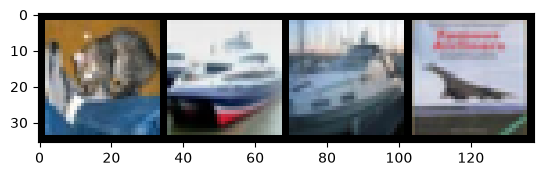

Label:         cat  ship  ship plane
Prediction:  plane plane  ship plane


In [10]:
# Load test dataset images (kept on CPU for plotting).
d_iter = iter(testloader)
im, ground_truth = next(d_iter)

imageshow(torchvision.utils.make_grid(im[:4]))
print("Label:      ", " ".join(f"{classes[ground_truth[j]]:>5}" for j in range(4)))

# Reconstruct the model with the same pooling operation used during training.
lenet_cached = LeNet(pool=nn.MaxPool2d(kernel_size=2, stride=2)).to(device)
state = torch.load(model_path, map_location=device, weights_only=True)
lenet_cached.load_state_dict(state)
lenet_cached.eval()

with torch.inference_mode():
    op = lenet_cached(im.to(device, non_blocking=True))
    pred = op.argmax(dim=1).cpu()

print("Prediction: ", " ".join(f"{classes[pred[j]]:>5}" for j in range(4)))

In [11]:
accuracy_max = test(lenet_cached, testloader)

LeNet accuracy on 10000 test images: 54.4 %


In [12]:
# class_sucess = list(0. for i in range(10))
# class_counter = list(0. for i in range(10))
# with torch.no_grad():
#     for data in testloader:
#         im, ground_truth = data
#         op = lenet_cached(im)
#         _, pred = torch.max(op, 1)
#         c = (pred == ground_truth).squeeze()
#         for i in range(1000):
#             ground_truth_curr = ground_truth[i]
#             class_sucess[ground_truth_curr] += c[i].item()
#             class_counter[ground_truth_curr] += 1


# for i in range(10):
#     print('Model accuracy for class %5s : %2d %%' % (
#         classes[i], 100 * class_sucess[i] / class_counter[i]))

### AvgPooling

In [13]:
torch.manual_seed(seed)
lenet_avg = LeNet(pool=nn.AvgPool2d(kernel_size=2, stride=2)).to(device)

In [14]:
# Define the optimizer.
optim_avg = torch.optim.SGD(
    lenet_avg.parameters(), lr=learning_rate, momentum=momentum
)
trainloader = make_trainloader()

# Testing every five epochs avoids a complete test-set pass after every epoch.
for epoch in range(num_epochs):
    train(lenet_avg, trainloader, optim_avg, epoch)
    if (epoch + 1) % eval_every == 0 or epoch + 1 == num_epochs:
        test(lenet_avg, testloader)
        print()

print("Finished Training")

Epoch 1 - Training Loss: 1.966
Epoch 2 - Training Loss: 1.567
Epoch 3 - Training Loss: 1.425
Epoch 4 - Training Loss: 1.347
Epoch 5 - Training Loss: 1.289
LeNet accuracy on 10000 test images: 53.4 %

Epoch 6 - Training Loss: 1.233
Epoch 7 - Training Loss: 1.192
Epoch 8 - Training Loss: 1.146
Epoch 9 - Training Loss: 1.109
Epoch 10 - Training Loss: 1.065
LeNet accuracy on 10000 test images: 54.5 %

Epoch 11 - Training Loss: 1.032
Epoch 12 - Training Loss: 1.001
Epoch 13 - Training Loss: 0.973
Epoch 14 - Training Loss: 0.941
Epoch 15 - Training Loss: 0.921
LeNet accuracy on 10000 test images: 55.7 %

Epoch 16 - Training Loss: 0.892
Epoch 17 - Training Loss: 0.882
Epoch 18 - Training Loss: 0.854
Epoch 19 - Training Loss: 0.832
Epoch 20 - Training Loss: 0.812
LeNet accuracy on 10000 test images: 55.4 %

Epoch 21 - Training Loss: 0.797
Epoch 22 - Training Loss: 0.785
Epoch 23 - Training Loss: 0.777
Epoch 24 - Training Loss: 0.755
Epoch 25 - Training Loss: 0.736
LeNet accuracy on 10000 test 

In [15]:
model_path = './cifar10_model_avgpool.pth'
torch.save(lenet_avg.state_dict(), model_path)

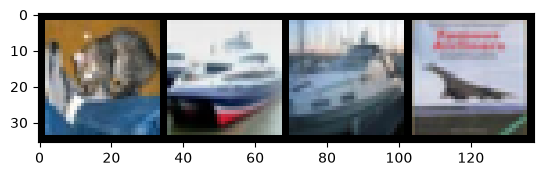

Label:         cat  ship  ship plane
Prediction:   deer   car  ship plane


In [16]:
# Load test dataset images (kept on CPU for plotting).
d_iter = iter(testloader)
im, ground_truth = next(d_iter)

imageshow(torchvision.utils.make_grid(im[:4]))
print("Label:      ", " ".join(f"{classes[ground_truth[j]]:>5}" for j in range(4)))

# Reconstruct the model with the same pooling operation used during training.
lenet_cached = LeNet(pool=nn.AvgPool2d(kernel_size=2, stride=2)).to(device)
state = torch.load(model_path, map_location=device, weights_only=True)
lenet_cached.load_state_dict(state)
lenet_cached.eval()

with torch.inference_mode():
    op = lenet_cached(im.to(device, non_blocking=True))
    pred = op.argmax(dim=1).cpu()

print("Prediction: ", " ".join(f"{classes[pred[j]]:>5}" for j in range(4)))

In [17]:
accuracy_avg = test(lenet_cached, testloader)

LeNet accuracy on 10000 test images: 53.0 %


In [18]:
# class_sucess = list(0. for i in range(10))
# class_counter = list(0. for i in range(10))
# with torch.no_grad():
#     for data in testloader:
#         im, ground_truth = data
#         op = lenet_cached(im)
#         _, pred = torch.max(op, 1)
#         c = (pred == ground_truth).squeeze()
#         for i in range(32):
#             ground_truth_curr = ground_truth[i]
#             class_sucess[ground_truth_curr] += c[i].item()
#             class_counter[ground_truth_curr] += 1


# for i in range(10):
#     print('Model accuracy for class %5s : %2d %%' % (
#         classes[i], 100 * class_sucess[i] / class_counter[i]))

### FuzzyPooling

In [19]:
torch.manual_seed(seed)
lenet_fzz = LeNet(pool=FuzzyPooling(tamanho_kernel=2, stride=2)).to(device)

In [20]:
# Define the optimizer.
optim_fzz = torch.optim.SGD(
    lenet_fzz.parameters(), lr=learning_rate, momentum=momentum
)
trainloader = make_trainloader()

# Testing every five epochs avoids a complete test-set pass after every epoch.
for epoch in range(num_epochs):
    train(lenet_fzz, trainloader, optim_fzz, epoch)
    if (epoch + 1) % eval_every == 0 or epoch + 1 == num_epochs:
        test(lenet_fzz, testloader)
        print()

print("Finished Training")

Epoch 1 - Training Loss: 1.990
Epoch 2 - Training Loss: 1.660
Epoch 3 - Training Loss: 1.553
Epoch 4 - Training Loss: 1.492
Epoch 5 - Training Loss: 1.430
LeNet accuracy on 10000 test images: 48.9 %

Epoch 6 - Training Loss: 1.381
Epoch 7 - Training Loss: 1.348
Epoch 8 - Training Loss: 1.324
Epoch 9 - Training Loss: 1.288
Epoch 10 - Training Loss: 1.262
LeNet accuracy on 10000 test images: 50.9 %

Epoch 11 - Training Loss: 1.239
Epoch 12 - Training Loss: 1.224
Epoch 13 - Training Loss: 1.200
Epoch 14 - Training Loss: 1.184
Epoch 15 - Training Loss: 1.169
LeNet accuracy on 10000 test images: 53.4 %

Epoch 16 - Training Loss: 1.153
Epoch 17 - Training Loss: 1.140
Epoch 18 - Training Loss: 1.132
Epoch 19 - Training Loss: 1.120
Epoch 20 - Training Loss: 1.110
LeNet accuracy on 10000 test images: 52.0 %

Epoch 21 - Training Loss: 1.093
Epoch 22 - Training Loss: 1.076
Epoch 23 - Training Loss: 1.082
Epoch 24 - Training Loss: 1.073
Epoch 25 - Training Loss: 1.058
LeNet accuracy on 10000 test 

In [21]:
model_path = './cifar10_model_fzzpool.pth'
torch.save(lenet_fzz.state_dict(), model_path)

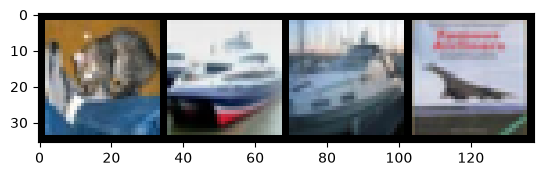

Label:         cat  ship  ship plane
Prediction:    cat truck  ship plane


In [22]:
# Load test dataset images (kept on CPU for plotting).
d_iter = iter(testloader)
im, ground_truth = next(d_iter)

imageshow(torchvision.utils.make_grid(im[:4]))
print("Label:      ", " ".join(f"{classes[ground_truth[j]]:>5}" for j in range(4)))

# Reconstruct the model with the same pooling operation used during training.
lenet_cached = LeNet(pool=FuzzyPooling(tamanho_kernel=2, stride=2)).to(device)
state = torch.load(model_path, map_location=device, weights_only=True)
lenet_cached.load_state_dict(state)
lenet_cached.eval()

with torch.inference_mode():
    op = lenet_cached(im.to(device, non_blocking=True))
    pred = op.argmax(dim=1).cpu()

print("Prediction: ", " ".join(f"{classes[pred[j]]:>5}" for j in range(4)))

In [23]:
accuracy_fzz = test(lenet_cached, testloader)

LeNet accuracy on 10000 test images: 55.0 %


In [24]:
# class_sucess = list(0. for i in range(10))
# class_counter = list(0. for i in range(10))
# with torch.no_grad():
#     for data in testloader:
#         im, ground_truth = data
#         op = lenet_cached(im)
#         _, pred = torch.max(op, 1)
#         c = (pred == ground_truth).squeeze()
#         for i in range(32):
#             ground_truth_curr = ground_truth[i]
#             class_sucess[ground_truth_curr] += c[i].item()
#             class_counter[ground_truth_curr] += 1


# for i in range(10):
#     print('Model accuracy for class %5s : %2d %%' % (
#         classes[i], 100 * class_sucess[i] / class_counter[i]))

In [25]:
paper_accuracy = {"MaxPooling": 70.73, "AvgPooling": 74.83, "FuzzyPooling": 78.35}
measured_accuracy = {
    "MaxPooling": accuracy_max,
    "AvgPooling": accuracy_avg,
    "FuzzyPooling": accuracy_fzz,
}
print("\nCIFAR-10 accuracy comparison")
for name in measured_accuracy:
    print(f"{name:14s} measured={measured_accuracy[name]:6.2f}%  paper={paper_accuracy[name]:6.2f}%")
print("Paper learning rate, momentum, epochs, initialization and exact architecture are not reported.")


CIFAR-10 accuracy comparison
MaxPooling     measured= 54.36%  paper= 70.73%
AvgPooling     measured= 53.01%  paper= 74.83%
FuzzyPooling   measured= 55.00%  paper= 78.35%
Paper learning rate, momentum, epochs, initialization and exact architecture are not reported.
